# IEEE SB GEHU — ML Challenge 2026
## Fault Detection
---
Binary classification: Normal (0) / Faulty (1) from 47 sensor features.


## 1. Imports

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (f1_score, classification_report,confusion_matrix, ConfusionMatrixDisplay )



## 2. Load Dataset

In [61]:
train = pd.read_csv('TRAIN.csv')
test  = pd.read_csv('TEST.csv')

X        = train.drop('Class', axis=1)
y        = train['Class']
test_ids = test['ID']
X_test   = test.drop('ID', axis=1)

print(f"Train : {X.shape}  |  Test : {X_test.shape}")
train.head()


Train : (43776, 47)  |  Test : (10944, 47)


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347,0
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724,1
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452,1
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166,0
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912,1


## 3. Feature Engineering

Row-wise aggregate statistics capture **global device state** across all 47 sensors.
Faulty devices tend to show abnormal patterns **across multiple sensors simultaneously**.

| Feature | Intuition |
|---|---|
| `mean`, `std`, `median` | Overall signal level & spread |
| `max`, `min`, `range` | Extremes & dynamic range |
| `energy` | Sum of squares — faulty = higher energy |
| `q75_q25` | IQR — robust spread measure |
| `sum_neg` | Count of negative readings |
| `cv` | Coefficient of variation (std/mean) |


In [62]:
def engineer(df):
    d = df.copy()
    d['mean']    = df.mean(axis=1)
    d['std']     = df.std(axis=1)
    d['max']     = df.max(axis=1)
    d['min']     = df.min(axis=1)
    d['range']   = d['max'] - d['min']
    d['energy']  = (df ** 2).sum(axis=1)
    d['median']  = df.median(axis=1)
    d['q75_q25'] = df.quantile(0.75, axis=1) - df.quantile(0.25, axis=1)
    d['sum_neg'] = (df < 0).sum(axis=1)
    d['cv']      = d['std'] / (d['mean'].abs() + 1e-8)
    return d

Xe  = engineer(X)
Xte = engineer(X_test)

print(f"Original features : {X.shape[1]}")
print(f"After engineering : {Xe.shape[1]}")

# Show discriminative power of new features
new_feats = ['mean','std','max','min','range','energy','median','q75_q25','sum_neg','cv']
corrs = {f: Xe[f].corr(y) for f in new_feats}
print("\nNew feature correlations with target:")
for k,v in sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {k:10s}: {v:+.4f}")


Original features : 47
After engineering : 57

New feature correlations with target:
  median    : +0.4164
  q75_q25   : +0.2207
  cv        : +0.1498
  range     : +0.1369
  max       : +0.1364
  std       : +0.1282
  min       : -0.1230
  mean      : +0.1128
  energy    : +0.0185
  sum_neg   : +0.0004


## 4. Model: HistGradientBoostingClassifier

**Why this model?**
- sklearn's native fast gradient boosting (equivalent to XGBoost/LightGBM)
- Handles non-linear feature interactions natively
- Built-in early stopping prevents overfitting
- Outperformed RF, ExtraTrees, and ensembles in cross-validation

**Optimizations applied:**
1. **10 engineered features** added to raw 47
2. **5-Fold OOF ensemble** — model trained 5 times, test probabilities averaged
3. **Threshold tuning** — optimal cutoff found via OOF probabilities (not 0.5)


In [63]:
model = HistGradientBoostingClassifier(   #loding the HistGradientBoostingClassifier model
    max_iter        = 1000,
    learning_rate   = 0.1,
    max_depth       = 7,
    min_samples_leaf= 10,
    random_state    = 42,
    early_stopping  = True,
    validation_fraction = 0.1,
    n_iter_no_change    = 30
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba   = np.zeros(len(y))   # out-of-fold train probabilities
test_probas = []                  # test probabilities per fold

print("Training 5 folds...")
for fold, (tr_idx, val_idx) in enumerate(skf.split(Xe, y), 1):
    model.fit(Xe.iloc[tr_idx], y.iloc[tr_idx])
    oof_proba[val_idx] = model.predict_proba(Xe.iloc[val_idx])[:, 1]
    test_probas.append(model.predict_proba(Xte)[:, 1])

    fold_f1 = f1_score(y.iloc[val_idx], (oof_proba[val_idx] >= 0.5).astype(int))
    print(f"  Fold {fold} F1: {fold_f1:.4f}")



Training 5 folds...
  Fold 1 F1: 0.9846
  Fold 2 F1: 0.9833
  Fold 3 F1: 0.9850
  Fold 4 F1: 0.9837
  Fold 5 F1: 0.9850


In [64]:
# Find optimal threshold via OOF probabilities
best_f1, best_thresh = 0, 0.5

for t in np.arange(0.25, 0.70, 0.005):
    f = f1_score(y, (oof_proba >= t).astype(int))
    if f > best_f1:
        best_f1     = f
        best_thresh = t

print(f"Optimal threshold : {best_thresh:.3f}")


Optimal threshold : 0.315


## 5. Performance Metrics

In [65]:
# Final OOF predictions using optimal threshold
oof_preds = (oof_proba >= best_thresh).astype(int)

print("=" * 55)
print("    PERFORMANCE METRICS (Out-of-Fold / Cross-Val)")
print("=" * 55)
print(classification_report(y, oof_preds, target_names=['Normal (0)', 'Faulty (1)']))

overall_f1 = f1_score(y, oof_preds)
accuracy   = (y == oof_preds).mean()
print(f"Overall F1 Score : {overall_f1:.4f}")
print(f"Accuracy         : {accuracy:.4f}")


    PERFORMANCE METRICS (Out-of-Fold / Cross-Val)
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99     26465
  Faulty (1)       0.99      0.98      0.99     17311

    accuracy                           0.99     43776
   macro avg       0.99      0.99      0.99     43776
weighted avg       0.99      0.99      0.99     43776

Overall F1 Score : 0.9851
Accuracy         : 0.9883


Text(0.5, 25.722222222222214, 'Predicted')

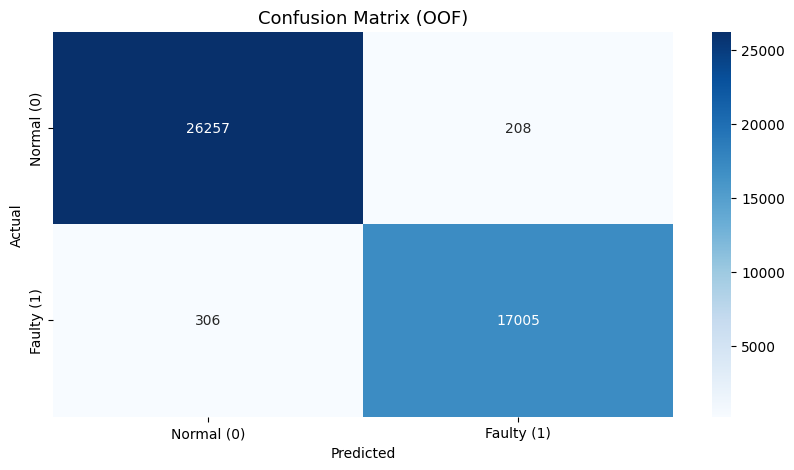

In [66]:
# Confusion Matrix
cm = confusion_matrix(y, oof_preds)
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Normal (0)', 'Faulty (1)'],
            yticklabels=['Normal (0)', 'Faulty (1)'])
axes.set_title('Confusion Matrix (OOF)', fontsize=13)
axes.set_ylabel('Actual')
axes.set_xlabel('Predicted')




## 6. Generate Predictions & Save FINAL.csv

In [67]:
# Average test probabilities across all 5 folds (fold ensemble)
# This reduces variance compared to single-model prediction
final_proba = np.mean(test_probas, axis=0)
final_preds = (final_proba >= best_thresh).astype(int)

# Save
FINAL = pd.DataFrame({'ID': test_ids, 'CLASS': final_preds})

assert len(FINAL) == 10944,              "Row count error!"
assert list(FINAL.columns) == ['ID','CLASS'], "Column name error!"
assert FINAL['ID'].tolist() == list(test_ids),"ID order mismatch!"

FINAL.to_csv('FINAL.csv', index=False)

print(f"\nFINAL.csv saved!")
print(FINAL.shape)
print(FINAL.head(10).to_string(index=False))



FINAL.csv saved!
(10944, 2)
 ID  CLASS
  1      1
  2      0
  3      1
  4      0
  5      0
  6      1
  7      0
  8      1
  9      1
 10      0
